In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# 모듈 import
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial import distance

In [ ]:
# 파일 경로 확인용
import os
path=os.getcwd()
print(path)

/content


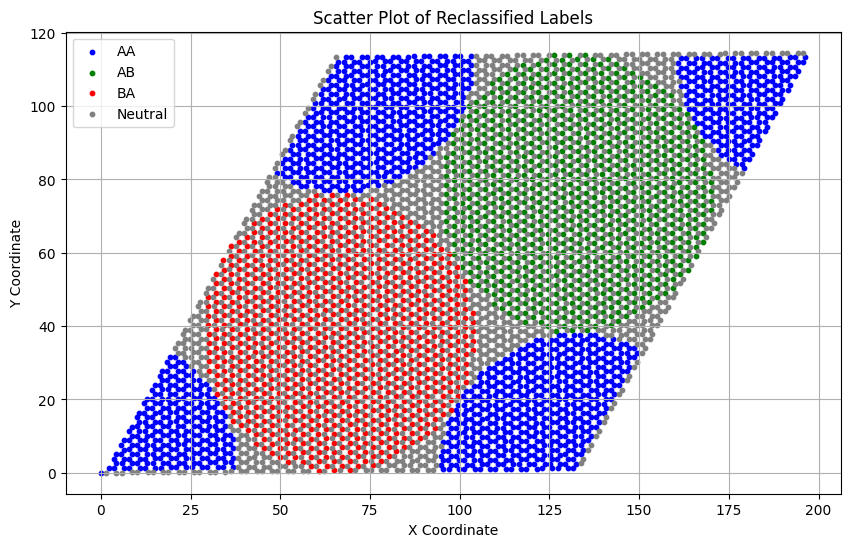

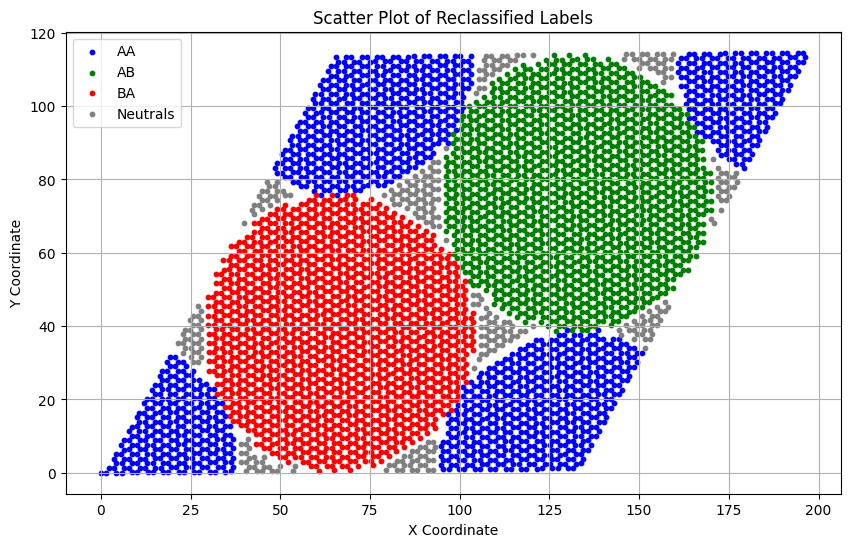

Epoch 0, Loss: 6.79813814163208, Accuracy: 29.63%
Epoch 10, Loss: 2.01235294342041, Accuracy: 29.56%
Epoch 20, Loss: 1.3148154020309448, Accuracy: 34.31%
Epoch 30, Loss: 1.2598800659179688, Accuracy: 46.52%
Epoch 40, Loss: 1.1663105487823486, Accuracy: 50.39%
Epoch 50, Loss: 1.1454747915267944, Accuracy: 49.72%
Epoch 60, Loss: 1.125776767730713, Accuracy: 51.02%
Epoch 70, Loss: 1.1166690587997437, Accuracy: 50.73%
Epoch 80, Loss: 1.1091902256011963, Accuracy: 50.64%
Epoch 90, Loss: 1.1019402742385864, Accuracy: 50.95%
Epoch 100, Loss: 1.0949512720108032, Accuracy: 50.97%
Epoch 110, Loss: 1.088091254234314, Accuracy: 50.88%
Epoch 120, Loss: 1.0812468528747559, Accuracy: 50.95%
Epoch 130, Loss: 1.0742509365081787, Accuracy: 51.06%
Epoch 140, Loss: 1.0663952827453613, Accuracy: 51.51%
Epoch 150, Loss: 1.0572094917297363, Accuracy: 52.30%
Epoch 160, Loss: 1.0465127229690552, Accuracy: 53.64%
Epoch 170, Loss: 1.0382941961288452, Accuracy: 54.00%
Epoch 180, Loss: 1.0299400091171265, Accuracy

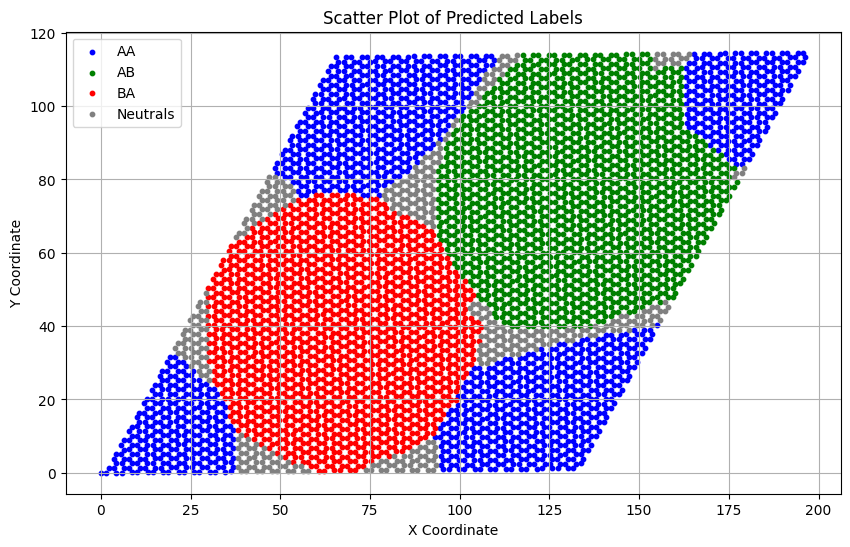

Point (50.0, 75.0) is classified as: Neutrals


In [ ]:
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import cKDTree

# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    return stacking

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmed:
        label = "Neutral"

    return label

def reclassify_neutral_points(df, k=5):
    """
    'Neutral'로 분류된 포인트들을 재분류하는 함수.

    주위 k개의 가장 가까운 이웃 포인트 중 'AA', 'AB', 'BA'가 있으면 해당 클래스로 재분류하고,
    그렇지 않으면 'Neutrals'로 유지합니다.

    Parameters:
    - df: 입력 데이터프레임
    - k: 가장 가까운 이웃 포인트의 수

    Returns:
    - df: 재분류된 데이터프레임
    """
    # 'Neutral'로 분류된 포인트들을 선택
    neutral_points = df[df['label'] == 'Neutral']

    if neutral_points.empty:
        return df

    # 'AA', 'AB', 'BA' 레이블을 가진 포인트들 선택
    non_neutral_points = df[df['label'].isin(['AA', 'AB', 'BA', 'Neutral'])]

    # KDTree 생성 (빠르게 가장 가까운 이웃을 찾기 위함)
    tree = cKDTree(non_neutral_points[['lower_x', 'lower_y']].values)

    # Neutral 포인트들에 대해 가장 가까운 k개의 이웃을 찾기
    for idx, point in neutral_points.iterrows():
        point_coords = np.array([[point['lower_x'], point['lower_y']]])
        distances, indices = tree.query(point_coords, k=k)

        # 가까운 k개의 이웃의 레이블을 확인
        neighbor_labels = non_neutral_points.iloc[indices[0]]['label'].values

        # 'AA', 'AB', 'BA' 중 가장 많은 레이블로 재분류
        if any(np.isin(neighbor_labels, ['AA', 'AB', 'BA'])):
            most_common_label = pd.Series(neighbor_labels).mode()[0]
            df.at[idx, 'label'] = most_common_label
        else:
            df.at[idx, 'label'] = 'Neutrals'

    return df

# 딥러닝 모델 (PyTorch 사용)
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 4)  # Output: 4 classes (AA, AB, BA, Neutrals)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 데이터를 학습할 함수
def train_model(df):
    X = df[['lower_x', 'lower_y']].values
    y = df['label'].replace({'AA': 0, 'AB': 1, 'BA': 2, 'Neutral': 3, 'Neutrals': 3}).values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # PyTorch Tensor로 변환
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # 학습
    for epoch in range(10000):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            _, predicted = torch.max(outputs.data, 1)
            accuracy = (predicted == y_train).sum().item() / y_train.size(0)
            print(f'Epoch {epoch}, Loss: {loss.item()}, Accuracy: {accuracy * 100:.2f}%')

    # 테스트
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs.data, 1)
        accuracy = (predicted == y_test).sum().item() / y_test.size(0)
        print(f'Test Accuracy: {accuracy * 100:.2f}%')

    return model

# 예측 함수
def predict(model, x, y):
    point = torch.tensor([[x, y]], dtype=torch.float32)
    with torch.no_grad():
        outputs = model(point)
        _, predicted = torch.max(outputs.data, 1)
    return ['AA', 'AB', 'BA', 'Neutrals'][predicted.item()]

# 학습 데이터에 대한 예측 및 시각화 함수
def plot_predictions(model, df):
    X = df[['lower_x', 'lower_y']].values
    y_true = df['label']

    # PyTorch Tensor로 변환하여 예측 수행
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        outputs = model(X_tensor)
        _, y_pred = torch.max(outputs.data, 1)

    # 예측된 레이블을 원래 레이블로 변환
    y_pred_labels = ['AA', 'AB', 'BA', 'Neutrals']
    y_pred = [y_pred_labels[pred] for pred in y_pred]

    # Scatter plot 생성
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutrals': 'gray'}

    for label in colors.keys():
        subset = X[np.array(y_pred) == label]
        plt.scatter(subset[:, 0], subset[:, 1], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Scatter Plot of Predicted Labels')
    plt.legend()
    plt.grid(True)
    plt.show()

# 전체 워크플로 실행
def main():
    # 데이터 경로 설정
    file_path = '/content/gdrive/MyDrive/Untitled Folder/rewq.txt'

    # 데이터 로드 및 전처리
    df = load_and_preprocess_data(file_path)
     # 분류된 데이터를 시각화
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutral': 'gray'}

    for label in colors.keys():
        subset = df[df['label'] == label]
        plt.scatter(subset['lower_x'], subset['lower_y'], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Scatter Plot of Reclassified Labels')
    plt.legend()
    plt.grid(True)
    plt.show()
    # 'Neutral' 포인트 재분류
    df = reclassify_neutral_points(df, k=5)

    # 재분류된 데이터를 시각화
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutrals': 'gray'}

    for label in colors.keys():
        subset = df[df['label'] == label]
        plt.scatter(subset['lower_x'], subset['lower_y'], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Scatter Plot of Reclassified Labels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 모델 학습
    model = train_model(df)

    # 학습 데이터의 예측 결과 시각화
    plot_predictions(model, df)

    # 임의의 지점 분류
    x_test = 50.0  # 예시 x 값
    y_test = 75.0  # 예시 y 값
    predicted_label = predict(model, x_test, y_test)
    print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

if __name__ == "__main__":
    main()


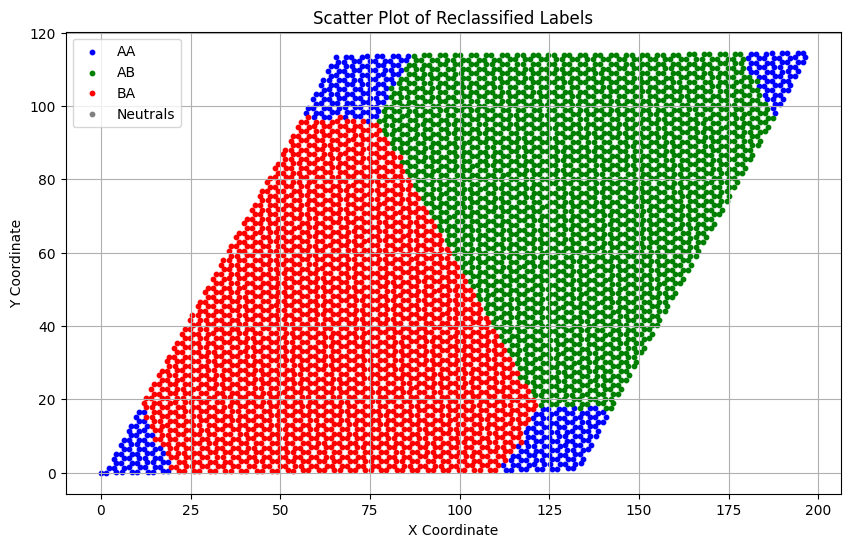

Epoch 0, Training Loss: 1.8989644050598145, Validation Loss: 1.3804361820220947
Epoch 10, Training Loss: 0.881434977054596, Validation Loss: 0.7998279929161072
Epoch 20, Training Loss: 0.8123773336410522, Validation Loss: 0.7741064429283142
Epoch 30, Training Loss: 0.7858729958534241, Validation Loss: 0.7438588738441467
Epoch 40, Training Loss: 0.7665032744407654, Validation Loss: 0.7314600944519043
Epoch 50, Training Loss: 0.7529414892196655, Validation Loss: 0.7204096913337708
Epoch 60, Training Loss: 0.7423108220100403, Validation Loss: 0.7103998064994812
Epoch 70, Training Loss: 0.7323538064956665, Validation Loss: 0.7031883001327515
Epoch 80, Training Loss: 0.7226676940917969, Validation Loss: 0.6935377717018127
Epoch 90, Training Loss: 0.7128459811210632, Validation Loss: 0.6846392154693604
Epoch 100, Training Loss: 0.7032362222671509, Validation Loss: 0.6756080985069275
Epoch 110, Training Loss: 0.693702757358551, Validation Loss: 0.6669573187828064
Epoch 120, Training Loss: 0.6

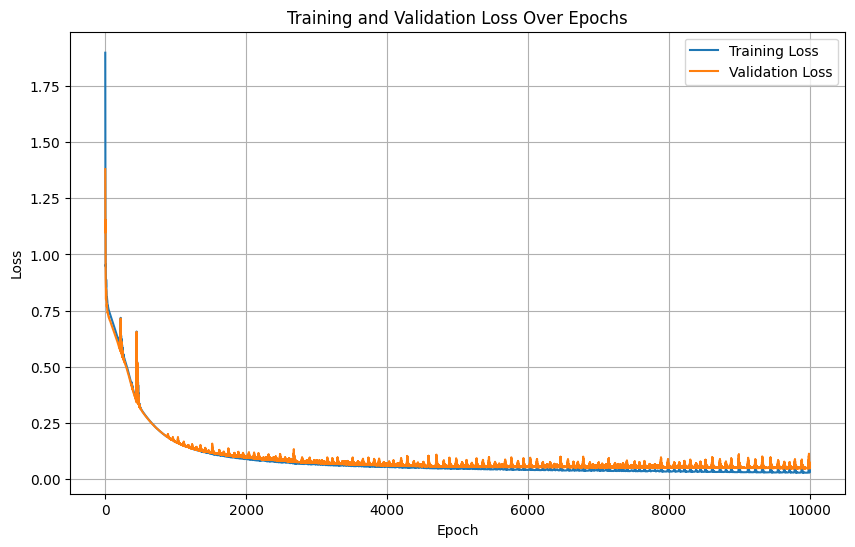

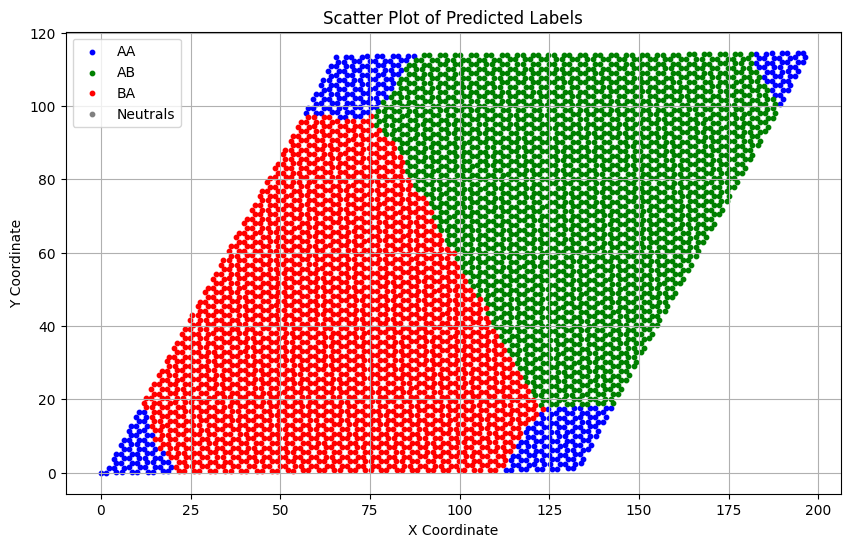

Point (50.0, 75.0) is classified as: BA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import cKDTree

# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    return stacking

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmed:
        label = "Neutral"

    return label

def reclassify_neutral_points(df, k=7):
    """
    'Neutral'로 분류된 포인트들을 재분류하는 함수.

    주위 k개의 가장 가까운 이웃 포인트 중 'AA', 'AB', 'BA'가 있으면 해당 클래스로 재분류하고,
    그렇지 않으면 'Neutrals'로 유지합니다.

    Parameters:
    - df: 입력 데이터프레임
    - k: 가장 가까운 이웃 포인트의 수

    Returns:
    - df: 재분류된 데이터프레임
    """
    # 'Neutral'로 분류된 포인트들을 선택
    neutral_points = df[df['label'] == 'Neutral']

    if neutral_points.empty:
        return df

    # 'AA', 'AB', 'BA' 레이블을 가진 포인트들 선택
    non_neutral_points = df[df['label'].isin(['AA', 'AB', 'BA'])]

    # KDTree 생성 (빠르게 가장 가까운 이웃을 찾기 위함)
    tree = cKDTree(non_neutral_points[['lower_x', 'lower_y']].values)

    # Neutral 포인트들에 대해 가장 가까운 k개의 이웃을 찾기
    for idx, point in neutral_points.iterrows():
        point_coords = np.array([[point['lower_x'], point['lower_y']]])
        distances, indices = tree.query(point_coords, k=k)

        # 가까운 k개의 이웃의 레이블을 확인
        neighbor_labels = non_neutral_points.iloc[indices[0]]['label'].values

        # 'AA', 'AB', 'BA' 중 가장 많은 레이블로 재분류
        if any(np.isin(neighbor_labels, ['AA', 'AB', 'BA'])):
            most_common_label = pd.Series(neighbor_labels).mode()[0]
            df.at[idx, 'label'] = most_common_label
        else:
            df.at[idx, 'label'] = 'Neutrals'

    return df

# 딥러닝 모델 (PyTorch 사용)
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 4)  # Output: 4 classes (AA, AB, BA, Neutrals)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 데이터를 학습할 함수
def train_model(df, num_epochs=5000):
    X = df[['lower_x', 'lower_y']].values
    y = df['label'].replace({'AA': 0, 'AB': 1, 'BA': 2, 'Neutrals': 3}).values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # PyTorch Tensor로 변환
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_weights = None

    # 학습
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Training loss 기록
        train_losses.append(loss.item())

        # Validation loss 계산
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test)
            val_losses.append(val_loss.item())

            # Best weight 저장
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_model_weights = model.state_dict()

        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Training Loss: {loss.item()}, Validation Loss: {val_loss.item()}')

    # Training loss와 Validation loss를 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Best model weight 로드
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model

# 예측 함수
def predict(model, x, y):
    point = torch.tensor([[x, y]], dtype=torch.float32)
    with torch.no_grad():
        outputs = model(point)
        _, predicted = torch.max(outputs.data, 1)
    return ['AA', 'AB', 'BA', 'Neutrals'][predicted.item()]

# 학습 데이터에 대한 예측 및 시각화 함수
def plot_predictions(model, df):
    X = df[['lower_x', 'lower_y']].values
    y_true = df['label']

    # PyTorch Tensor로 변환하여 예측 수행
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        outputs = model(X_tensor)
        _, y_pred = torch.max(outputs.data, 1)

    # 예측된 레이블을 원래 레이블로 변환
    y_pred_labels = ['AA', 'AB', 'BA', 'Neutrals']
    y_pred = [y_pred_labels[pred] for pred in y_pred]

    # Scatter plot 생성
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutrals': 'gray'}

    for label in colors.keys():
        subset = X[np.array(y_pred) == label]
        plt.scatter(subset[:, 0], subset[:, 1], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Scatter Plot of Predicted Labels')
    plt.legend()
    plt.grid(True)
    plt.show()

# 전체 워크플로 실행
def main():
    # 데이터 경로 설정
    file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

    # 데이터 로드 및 전처리
    df = load_and_preprocess_data(file_path)

    # 'Neutral' 포인트 재분류
    df = reclassify_neutral_points(df, k=5)

    # 재분류된 데이터를 시각화
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutrals': 'gray'}

    for label in colors.keys():
        subset = df[df['label'] == label]
        plt.scatter(subset['lower_x'], subset['lower_y'], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Scatter Plot of Reclassified Labels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 모델 학습 및 Training/Validation Loss 시각화
    model = train_model(df, num_epochs=10000)

    # 학습 데이터의 예측 결과 시각화
    plot_predictions(model, df)

    # 임의의 지점 분류
    x_test = 50.0  # 예시 x 값
    y_test = 75.0  # 예시 y 값
    predicted_label = predict(model, x_test, y_test)
    print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

if __name__ == "__main__":
    main()


In [ ]:
x_test = 0.1  # 예시 x 값
y_test = 0.1  # 예시 y 값
predicted_label = predict(model, x_test, y_test)
print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

Point (0.1, 0.1) is classified as: BA


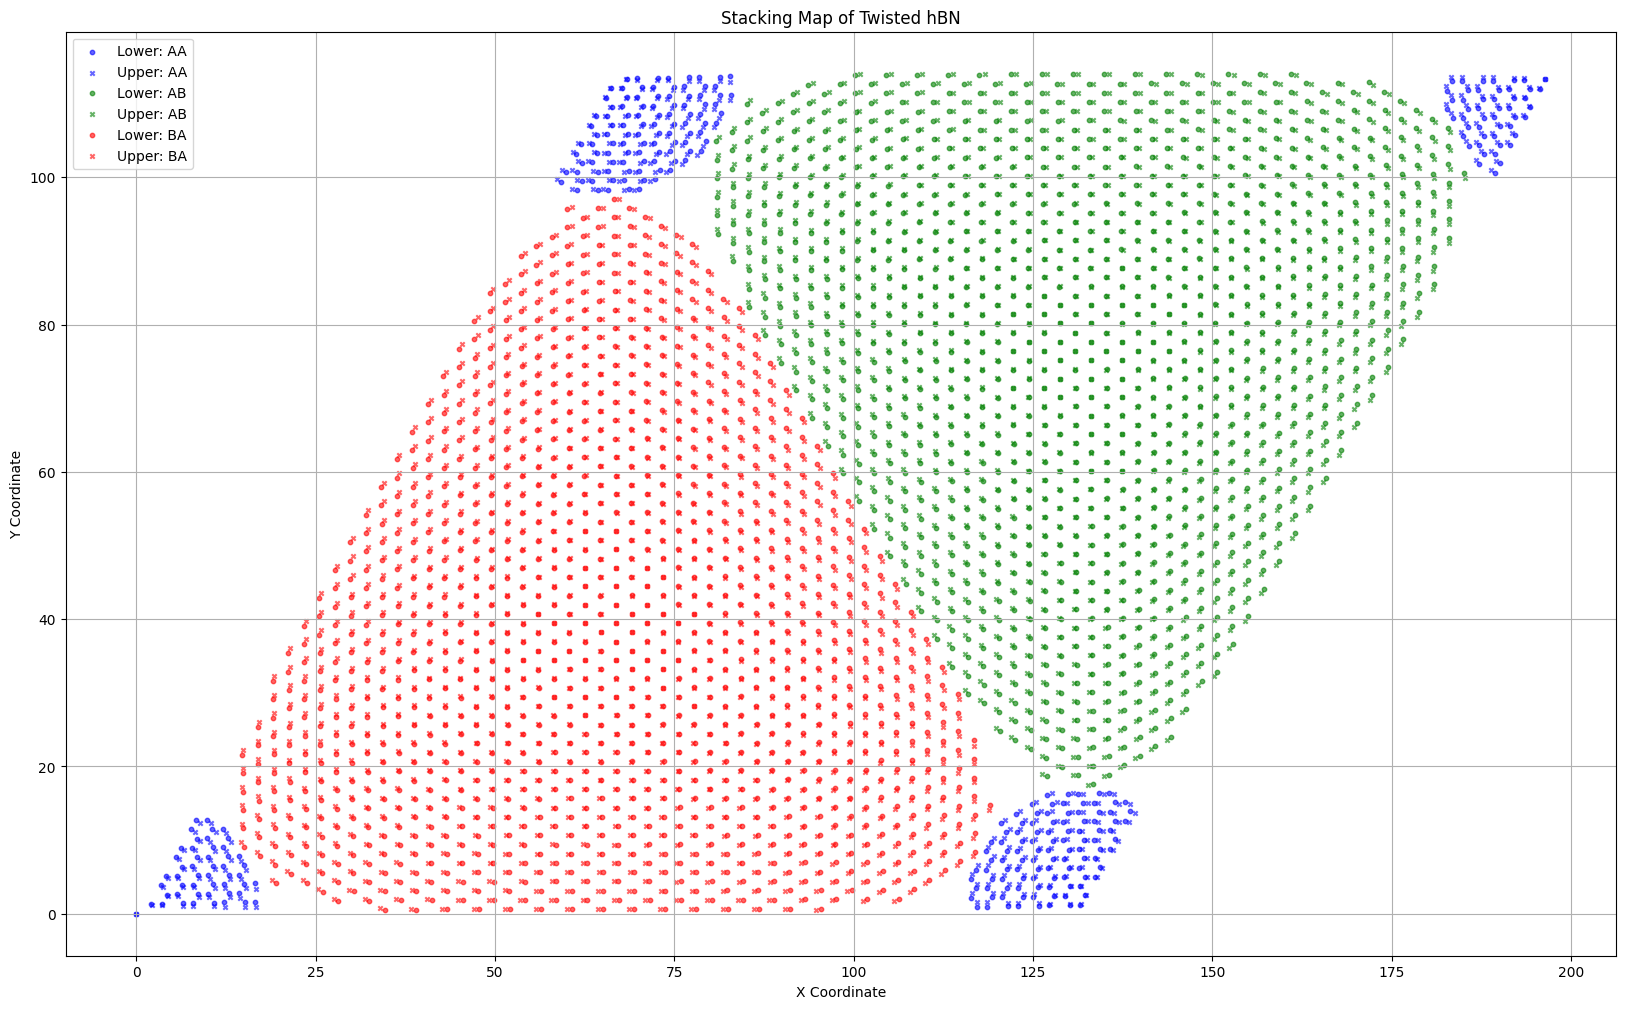

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial import distance

# Load the data from the file
file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

# Read the file content
with open(file_path, 'r') as file:
    data = file.read()

atoms = []
for line in data.splitlines():
    if line.startswith("ITEM: ATOMS"):
        continue
    elif line.startswith("ITEM") or line.startswith("0"):
        continue
    else:
        atom_info = line.split()
        if len(atom_info) == 8:
            atom_id = int(atom_info[0])
            atom_type = int(atom_info[1])
            x = float(atom_info[2])
            y = float(atom_info[3])
            z = float(atom_info[4])
            atoms.append((atom_id, atom_type, x, y, z))

df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

# 윗 층과 아랫 층 나누기
upper_layer = df[df['type'].isin([1, 2])]
lower_layer = df[df['type'].isin([3, 4])]
# 윗 층의 x,y 좌표 추출
u_coords = upper_layer[['x', 'y', 'type']]
# 윗 층에서 가장 가까운 두 점 찾기 (d 계산)
d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:,:2], axis=1))[1] for l1 in u_coords.values[:,:2]])
dmed=np.median(d)
dmed /= 2  # d를 2로 나눔

#아랫 층의 x,y 좌표 추출
l_coords = lower_layer[['x', 'y', 'type']]

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# Calculate the minimum distance and associated upper point for each lower point
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)  # l2 distance
    min_index = np.argmin(distances)  # Find the index of the closest point
    return upper_points[min_index]

atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

# `xy` 배열 생성 및 DataFrame 변환
xy = np.concatenate((l_coords.values, atom_identify), axis=1)

stacking = pd.DataFrame(xy, columns=['lx', 'ly', 'ltype', 'ux', 'uy', 'utype'])

# 동일한 레이블 할당 함수 적용
def assign_label(row):
    lx, ly, ltype, ux, uy, utype = row['lx'], row['ly'], row['ltype'], row['ux'], row['uy'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > 1*dmed:
        label = "Neutral"

    return label

# 'stack' 열을 추가하고 레이블을 할당
stacking['stack'] = stacking.apply(assign_label, axis=1)

# 색상 설정 및 플롯 생성
color_map = {
    'AA': 'blue',
    'AB': 'green',
    'BA': 'red',
 #   'Neutral': 'gray',
#    'exception': 'black'
}

plt.figure(figsize=(20, 12))

for label, color in color_map.items():
    subset = stacking[stacking['stack'] == label]
    plt.scatter(subset['lx'], subset['ly'], s=10, color=color, alpha=0.6, label=f'Lower: {label}', marker='o')
    plt.scatter(subset['ux'], subset['uy'], s=10, color=color, alpha=0.6, label=f'Upper: {label}', marker='x')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Stacking Map of Twisted hBN')
plt.legend()
plt.grid(True)
plt.savefig('hBN_stackingmap.jpeg')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    return stacking

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmed:
        label = "Neutral"

    return label

from scipy.spatial import cKDTree

def reclassify_neutral_points(df, k=7):
    """
    'Neutral'로 분류된 포인트들을 재분류하는 함수.

    주위 k개의 가장 가까운 이웃 포인트 중 'AA', 'AB', 'BA'가 있으면 해당 클래스로 재분류하고,
    그렇지 않으면 'Neutrals'로 유지합니다.

    Parameters:
    - df: 입력 데이터프레임
    - k: 가장 가까운 이웃 포인트의 수

    Returns:
    - df: 재분류된 데이터프레임
    """
    # 'Neutral'로 분류된 포인트들을 선택
    neutral_points = df[df['label'] == 'Neutral']

    if neutral_points.empty:
        return df

    # 'AA', 'AB', 'BA' 레이블을 가진 포인트들 선택
    non_neutral_points = df[df['label'].isin(['AA', 'AB', 'BA'])]

    # KDTree 생성 (빠르게 가장 가까운 이웃을 찾기 위함)
    tree = cKDTree(non_neutral_points[['lower_x', 'lower_y']].values)

    # Neutral 포인트들에 대해 가장 가까운 k개의 이웃을 찾기
    for idx, point in neutral_points.iterrows():
        point_coords = np.array([[point['lower_x'], point['lower_y']]])
        distances, indices = tree.query(point_coords, k=k)

        # 가까운 k개의 이웃의 레이블을 확인
        neighbor_labels = non_neutral_points.iloc[indices[0]]['label'].values

        # 'AA', 'AB', 'BA' 중 가장 많은 레이블로 재분류
        if any(np.isin(neighbor_labels, ['AA', 'AB', 'BA'])):
            most_common_label = pd.Series(neighbor_labels).mode()[0]
            df.at[idx, 'label'] = most_common_label
        else:
            df.at[idx, 'label'] = 'Neutrals'

    return df



# DBSCAN을 사용하여 Neutral 포인트를 재분류하는 함수
def reclassify_neutral_points_with_dbscan(df, eps=3, min_samples=5):
    neutral_points = df[df['label'] == 'Neutral']
    if neutral_points.empty:
        return df

    # AB, AA, BA만 사용하여 DBSCAN을 수행할 데이터 준비
    df_no_neutral = df[df['label'].isin(['AB', 'AA', 'BA'])]
    X = df_no_neutral[['lower_x', 'lower_y']]
    y = df_no_neutral['label']

    # DBSCAN 클러스터링
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X)

    # Cluster labels
    df_no_neutral['cluster'] = dbscan.labels_

    # DBSCAN 결과를 사용하여 Neutral 포인트 재분류
    for idx, point in neutral_points.iterrows():
        point_coords = np.array([[point['lower_x'], point['lower_y']]])
        distances = np.linalg.norm(X.values - point_coords, axis=1)
        nearest_neighbors = np.argsort(distances)[:min_samples]
        neighbor_labels = y.iloc[nearest_neighbors]

        # 주변에 AA, AB, BA가 하나라도 있는지 확인
        if any(neighbor_labels.isin(['AB', 'AA', 'BA'])):
            most_common_label = neighbor_labels.mode()[0]
            df.at[idx, 'label'] = most_common_label
        else:
            df.at[idx, 'label'] = "Neutrals"

    return df

# 딥러닝 모델 (PyTorch 사용)
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 4)  # Output: 4 classes (AA, AB, BA, Neutrals)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 데이터를 학습할 함수
def train_model(df):
    X = df[['lower_x', 'lower_y']].values
    y = df['label'].replace({'AA': 0, 'AB': 1, 'BA': 2, 'Neutrals': 3}).values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # PyTorch Tensor로 변환
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # 학습
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            _, predicted = torch.max(outputs.data, 1)
            accuracy = (predicted == y_train).sum().item() / y_train.size(0)
            print(f'Epoch {epoch}, Loss: {loss.item()}, Accuracy: {accuracy * 100:.2f}%')

    # 테스트
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs.data, 1)
        accuracy = (predicted == y_test).sum().item() / y_test.size(0)
        print(f'Test Accuracy: {accuracy * 100:.2f}%')

    return model

# 예측 함수
def predict(model, x, y):
    point = torch.tensor([[x, y]], dtype=torch.float32)
    with torch.no_grad():
        outputs = model(point)
        _, predicted = torch.max(outputs.data, 1)
    return ['AA', 'AB', 'BA', 'Neutrals'][predicted.item()]


# 데이터 경로 설정
file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

df = load_and_preprocess_data(file_path)

# 'Neutral' 포인트 재분류
df = reclassify_neutral_points(df)

print(df)
# # 데이터 로드 및 전처리
# df = load_and_preprocess_data(file_path)

# # DBSCAN을 사용하여 Neutral 포인트 재분류
# df = reclassify_neutral_points_with_dbscan(df)

# # 모델 학습
# model = train_model(df)

# # 임의의 지점 분류
# x_test = 50.0  # 예시 x 값
# y_test = 75.0  # 예시 y 값
# predicted_label = predict(model, x_test, y_test)
# print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")



         lower_x     lower_y    lower_z  ltype     upper_x     upper_y  \
0      64.088702  110.800535  20.893565    3.0   65.357754  110.868643   
1      66.228708  112.104005  20.899151    3.0   66.110231  112.104074   
2      68.368317  113.407781  20.899005    3.0   68.309140  113.305142   
3      62.004040  106.994492  20.871383    3.0   63.103563  107.161107   
4      64.146184  108.296109  20.883837    3.0   63.854260  108.397491   
...          ...         ...        ...    ...         ...         ...   
5577  131.527223    3.740240  20.903626    4.0  131.704470    3.774322   
5578  133.667526    5.043657  20.898274    4.0  133.902690    4.975732   
5579  135.808867    6.346095  20.888968    4.0  134.653861    6.211763   
5580  131.586154    1.235285  20.909304    4.0  131.645543    1.269573   
5581  133.725868    2.539060  20.906562    4.0  132.398177    2.504879   

        upper_z  utype  distance label  
0     17.357468    2.0  1.270878    AA  
1     17.362091    1.0  0.118

In [ ]:
    x_test = 0.0  # 예시 x 값
    y_test = 0.0  # 예시 y 값
    predicted_label = predict(model, x_test, y_test)
    print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

Point (0.0, 0.0) is classified as: BA


In [ ]:
# 머신러닝 모델 학습 및 평가 함수
def train_and_evaluate_model(df):
    # 특징 추출
    X = df[['upper_x', 'upper_y', 'upper_z', 'lower_x', 'lower_y', 'lower_z', 'distance']]
    y = df['label']

    # 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # RandomForestClassifier 사용
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 정확도 평가
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model accuracy: {accuracy * 100:.2f}%")

    return model

# Load the data from the file
file_path = '/content/gdrive/MyDrive/Untitled Folder/dump.minimization'

# Read the file content
with open(file_path, 'r') as file:
    data = file.read()

# Parse and preprocess the data
df = parse_and_preprocess(data)

# Train and evaluate the model
model = train_and_evaluate_model(df)

In [ ]:
label_counts = stacking['stack'].value_counts()

print(label_counts)
label_counts2 = stacking['utype'].value_counts()

print(label_counts2)

KeyError: 'stack'

In [ ]:
label_counts = stacking['stack'].value_counts()

print(label_counts)

stack
Neutral    2753
BA         1260
AB         1260
AA          309
Name: count, dtype: int64


In [ ]:
label_counts2 = stacking['utype'].value_counts()

print(label_counts2)

utype
1.0    2801
2.0    2781
Name: count, dtype: int64


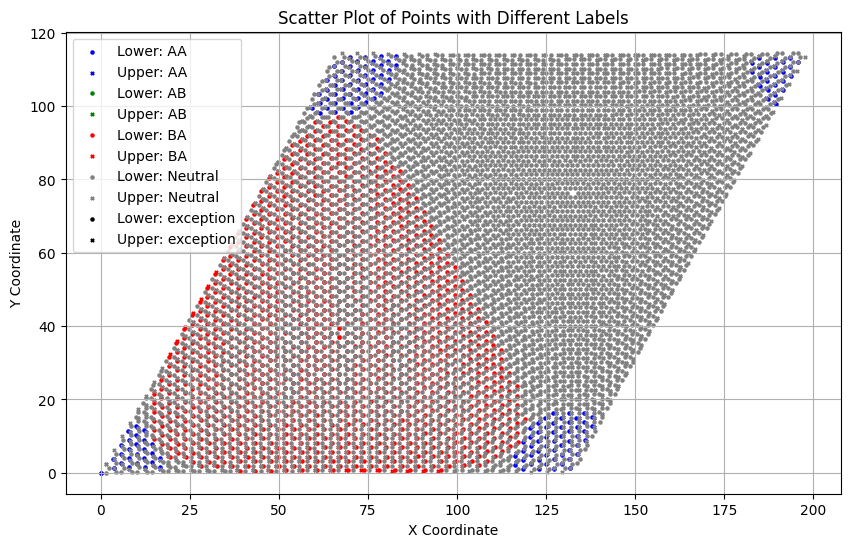

In [ ]:
import matplotlib.pyplot as plt
# 색상 설정
color_map = {
    'AA': 'blue',
    'AB': 'green',
    'BA': 'red',
    'Neutral': 'gray',
    'exception': 'black'
}

# 플롯 생성
plt.figure(figsize=(10, 6))

# 각 레이블에 대해 색상으로 점을 그리기
for label, color in color_map.items():
    subset = stacking[stacking['stack'] == label]
    plt.scatter(subset['lx'], subset['ly'], s=5, color=color, label=f'Lower: {label}', marker='o')
    plt.scatter(subset['ux'], subset['uy'], s=5, color=color, label=f'Upper: {label}', marker='x')

# 레이블 추가
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Scatter Plot of Points with Different Labels')
plt.legend()
plt.grid(True)
plt.show()

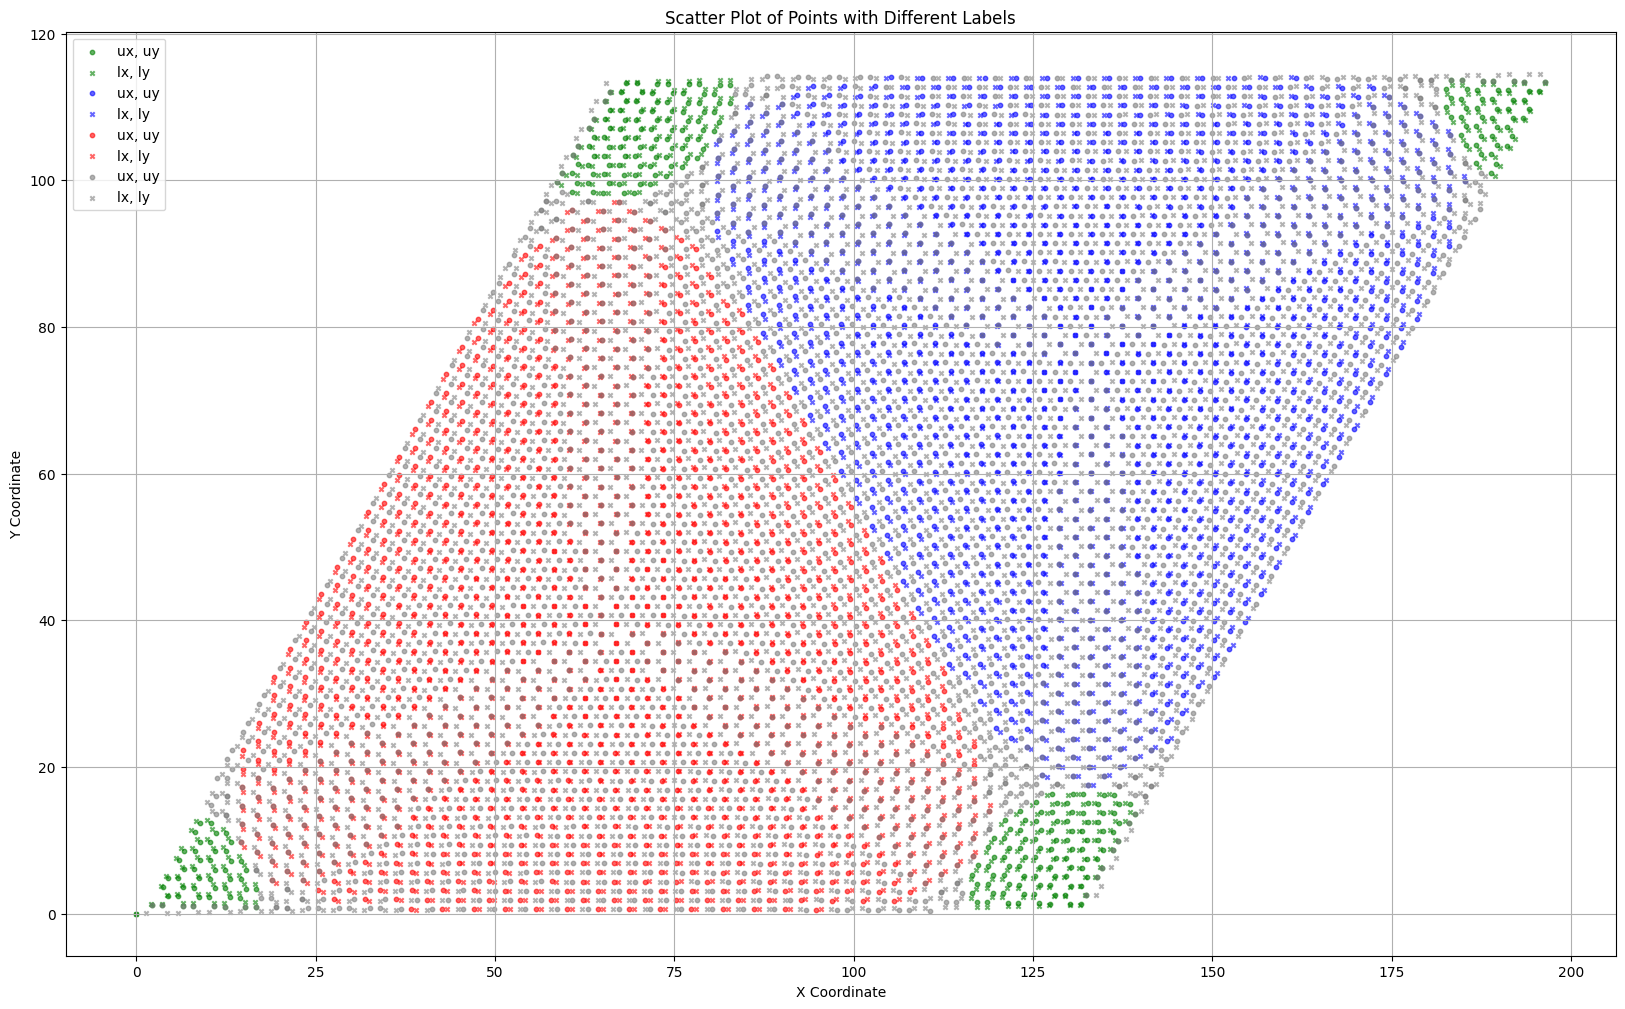

In [ ]:
# 색상 설정
from matplotlib.colors import ListedColormap
color_map = {
    'AA': 'blue',
    'AB': 'green',
    'BA': 'red',
    'Neutral': 'gray',
    'exception': 'black'
}

# # 플롯 생성
# plt.figure(figsize=(10, 6))

# 각 레이블에 대해 색상으로 점을 그리기
# for label, color in color_map.items():
#     subset = stacking[stacking['stack'] == label]
#     plt.scatter(subset['lx'], subset['ly'], color=color, label=f'Lower: {label}', marker='o')
#     plt.scatter(subset['ux'], subset['uy'], color=color, label=f'Upper: {label}', marker='x')
# plt.scatter(stacking['ux'],stacking['uy'], cmap=stacking['stack'],marker='.',s=10)
# 윗 층과 아랫 층 나누기
AAs = stacking[stacking['stack'].isin(['AA'])]
ABs = stacking[stacking['stack'].isin(['AB'])]
BAs = stacking[stacking['stack'].isin(['BA'])]
Neus = stacking[stacking['stack'].isin(['Neutral'])]
Exs = stacking[stacking['stack'].isin(['exception'])]

# 산점도 그리기
plt.figure(figsize=(20, 12))

# ux, uy 점 그리기
plt.scatter(AAs['ux'], AAs['uy'],marker='o', color='green', s=10, alpha=0.6, label='ux, uy')
plt.scatter(AAs['lx'], AAs['ly'], marker='x', color='green', s=10, alpha=0.6, label='lx, ly')
plt.scatter(ABs['ux'], ABs['uy'],marker='o', color='blue', s=10, alpha=0.6, label='ux, uy')
plt.scatter(ABs['lx'], ABs['ly'], marker='x', color='blue', s=10, alpha=0.6, label='lx, ly')
plt.scatter(BAs['ux'], BAs['uy'],marker='o', color='red', s=10, alpha=0.6, label='ux, uy')
plt.scatter(BAs['lx'], BAs['ly'], marker='x', color='red',s=10, alpha=0.6, label='lx, ly')
plt.scatter(Neus['ux'], Neus['uy'],marker='o', color='gray', s=10, alpha=0.6, label='ux, uy')
plt.scatter(Neus['lx'], Neus['ly'], marker='x', color='gray', s=10, alpha=0.6, label='lx, ly')
# plt.scatter(Exs['ux'], Exs['uy'],marker='o', s=15, alpha=0.6, label='ux, uy')
# plt.scatter(Exs['lx'], Exs['ly'], marker='x', s=15, alpha=0.6, label='lx, ly')


# 레이블 추가
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Scatter Plot of Points with Different Labels')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Load the data from the file
file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

# Read the file content
with open(file_path, 'r') as file:
    data = file.read()


def comb_distance(data):
    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0") or line.startswith("1"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    # 윗 층의 좌표 추출
    coords = upper_layer[['x', 'y']].to_numpy()
    print(coords[:,:2])
    # 윗 층에서 가장 가까운 두 점 찾기 (d 계산)
    #min_distance = np.array([np.min(np.linalg.norm(l1 - coords, axis=1)) for l1 in coords])
    d = np.array([np.sort(np.linalg.norm(l1 - coords[:,:2], axis=1))[1] for l1 in coords[:,:2]])
    return d
d=comb_distance(data)
print(d)

[[6.83091396e+01 1.13305142e+02]
 [7.05079800e+01 1.14506706e+02]
 [6.38542597e+01 1.08397491e+02]
 ...
 [1.33902690e+02 4.97573168e+00]
 [1.29446584e+02 6.84139811e-02]
 [1.31645543e+02 1.26957323e+00]]
[1.44652616 1.44657491 1.44632607 ... 1.44638573 1.44654442 1.44652622]


In [ ]:
np.min(d)

1.4421225006072256

In [ ]:
a=np.array([[1, 2],[3, 4],[5, 6]])
b=np.array([[0, 1],[2, 3],[4, 5]])
c = np.linalg.norm(a - b, axis=1)
print(c)

[1.41421356 1.41421356 1.41421356]


In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# from scipy.spatial import distance

# # 데이터 파싱 및 전처리 함수
# def parse_and_preprocess(data):
#     atoms = []
#     for line in data.splitlines():
#         if line.startswith("ITEM: ATOMS"):
#             continue
#         elif line.startswith("ITEM") or line.startswith("0") or line.startswith("1"):
#             continue
#         else:
#             atom_info = line.split()
#             if len(atom_info) == 8:
#                 atom_id = int(atom_info[0])
#                 atom_type = int(atom_info[1])
#                 x = float(atom_info[2])
#                 y = float(atom_info[3])
#                 z = float(atom_info[4])
#                 atoms.append((atom_id, atom_type, x, y, z))

#     df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

#     # 윗 층과 아랫 층 나누기
#     upper_layer = df[df['type'].isin([1, 2])]
#     lower_layer = df[df['type'].isin([3, 4])]

#     # 윗 층의 x,y 좌표 추출
#     u_coords = upper_layer[['x', 'y']].to_numpy()
#     #print(u_coords[:,:2])
#     # 윗 층에서 가장 가까운 두 점 찾기 (d 계산)
#     #min_distance = np.array([np.min(np.linalg.norm(l1 - u_coords, axis=1)) for l1 in u_coords])
#     d = np.array([np.sort(np.linalg.norm(l1 - u_coords[:,:2], axis=1))[1] for l1 in u_coords[:,:2]])
#     dmed=np.median(d)
#     dmed /= 2  # d를 2로 나눔

#     #아랫 층의 x,y 좌표 추출
#     l_coords = lower_layer[['x', 'y']].to_numpy()
#     z = np.array([np.sort(np.linalg.norm(l1 - u_coords[:,:2], axis=1))[0] for l1 in l_coords[:,:2]])
#     zmin=np.min(z)

#     # 윗 층의 각 점과 아랫 층의 가장 가까운 점 찾기
#     data = []
#     for _, upper_point in upper_layer.iterrows():
#         closest_dist = float('inf')
#         closest_lower_point = None

#         for _, lower_point in lower_layer.iterrows():
#             dist = distance.euclidean((upper_point['x'], upper_point['y']), (lower_point['x'], lower_point['y']))
#             if dist < closest_dist:
#                 closest_dist = dist
#                 closest_lower_point = lower_point

#         # 레이블 할당
#         if upper_point['type'] == 1 and closest_lower_point['type'] == 3:
#             label = "AA"
#         elif upper_point['type'] == 2 and closest_lower_point['type'] == 4:
#             label = "AA"
#         elif upper_point['type'] == 1 and closest_lower_point['type'] == 4:
#             label = "AB"
#         elif upper_point['type'] == 2 and closest_lower_point['type'] == 3:
#             label = "BA"
#         else:
#             label = "Neutral"

#         # 거리 조건으로 Neutral 업데이트
#         if closest_dist > dmed:
#             label = "Neutral"

#         data.append({
#             'upper_x': upper_point['x'],
#             'upper_y': upper_point['y'],
#             'upper_z': upper_point['z'],
#             'lower_x': closest_lower_point['x'],
#             'lower_y': closest_lower_point['y'],
#             'lower_z': closest_lower_point['z'],
#             'distance': closest_dist,
#             'label': label
#         })

#     return pd.DataFrame(data)

# # 머신러닝 모델 학습 및 평가 함수
# def train_and_evaluate_model(df):
#     # 특징 추출
#     X = df[['upper_x', 'upper_y', 'upper_z', 'lower_x', 'lower_y', 'lower_z', 'distance']]
#     y = df['label']

#     # 데이터 분할
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     # RandomForestClassifier 사용
#     model = RandomForestClassifier(random_state=42)
#     model.fit(X_train, y_train)

#     # 예측
#     y_pred = model.predict(X_test)

#     # 정확도 평가
#     accuracy = accuracy_score(y_test, y_pred)
#     print(f"Model accuracy: {accuracy * 100:.2f}%")

#     return model

# # Load the data from the file
# file_path = '/content/gdrive/MyDrive/Untitled Folder/dump.minimization'

# # Read the file content
# with open(file_path, 'r') as file:
#     data = file.read()

# # Parse and preprocess the data
# df = parse_and_preprocess(data)

# # Train and evaluate the model
# model = train_and_evaluate_model(df)

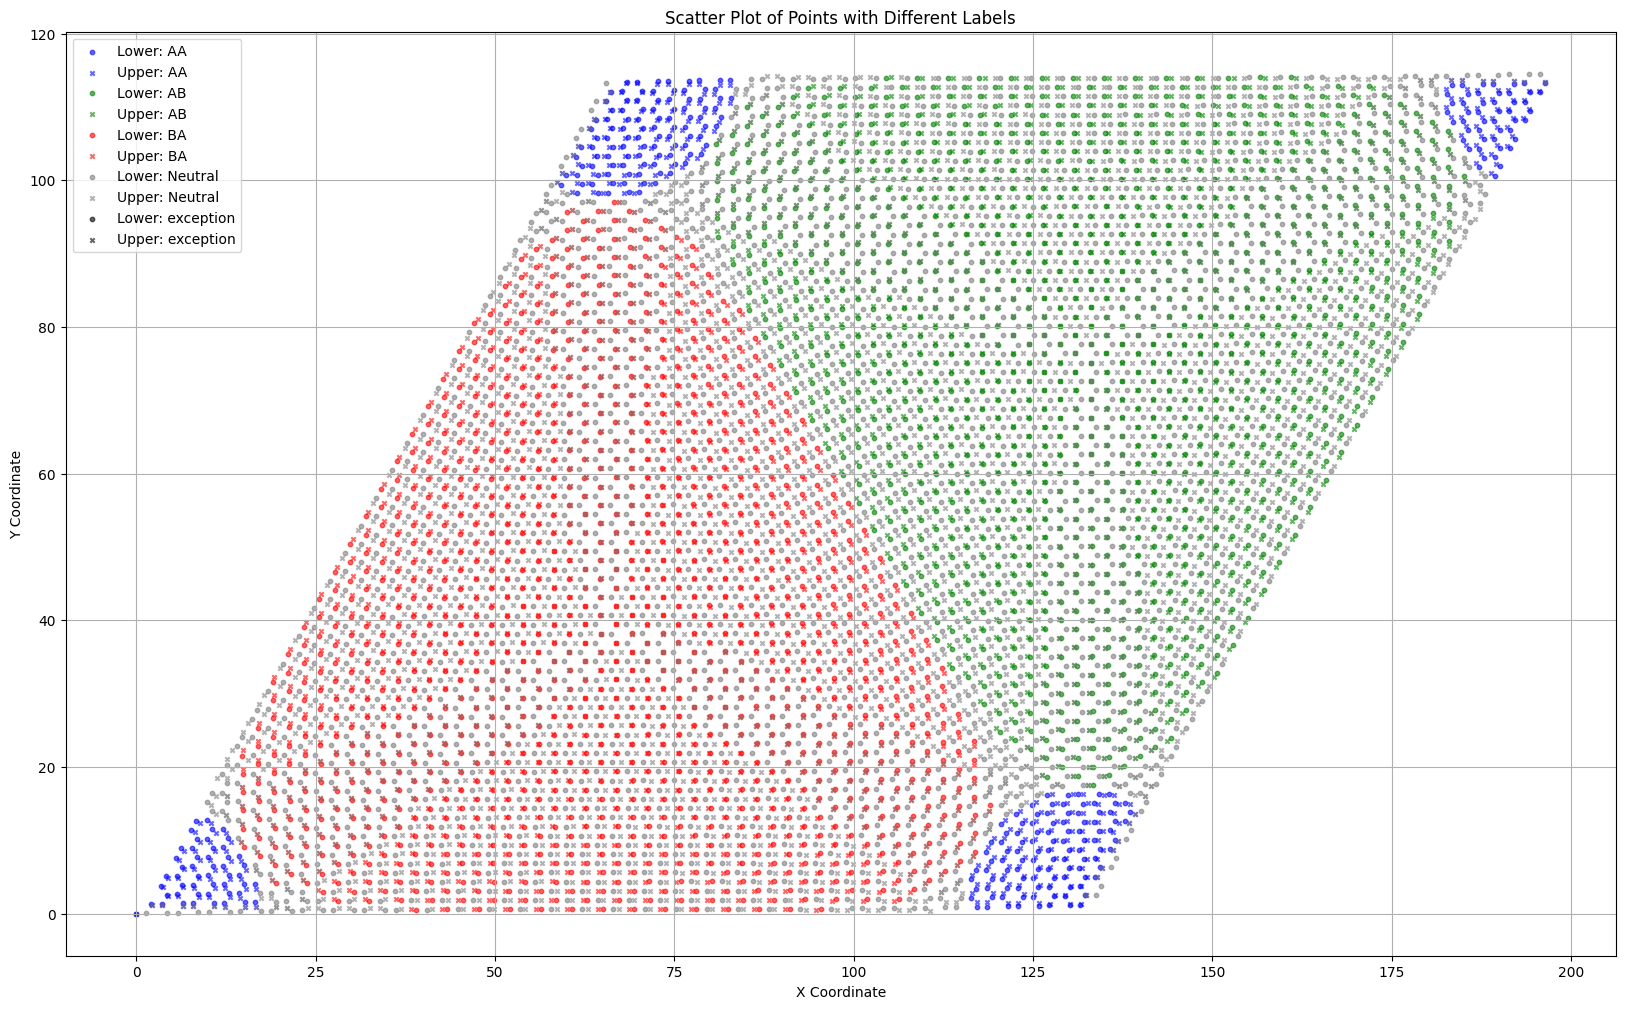

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data and create DataFrame as described in your code
# ...

# 위의 코드에서 `u_coords`와 `l_coords` DataFrame이 이미 정의되었음을 가정합니다.

# Calculate the minimum distance and associated upper point for each lower point
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)  # l2 distance
    min_index = np.argmin(distances)  # Find the index of the closest point
    return upper_points[min_index]

# atom_identify를 새로운 방식으로 생성
atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

# `xy` 배열 생성 및 DataFrame 변환
xy = np.concatenate((l_coords.values, atom_identify), axis=1)

stacking = pd.DataFrame(xy, columns=['lx', 'ly', 'ltype', 'ux', 'uy', 'utype'])

# 동일한 레이블 할당 함수 적용
def assign_label(row):
    lx, ly, ltype, ux, uy, utype = row['lx'], row['ly'], row['ltype'], row['ux'], row['uy'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmin:
        label = "Neutral"

    return label

# 'stack' 열을 추가하고 레이블을 할당
stacking['stack'] = stacking.apply(assign_label, axis=1)

# 색상 설정 및 플롯 생성
color_map = {
    'AA': 'blue',
    'AB': 'green',
    'BA': 'red',
    'Neutral': 'gray',
    'exception': 'black'
}

plt.figure(figsize=(20, 12))

for label, color in color_map.items():
    subset = stacking[stacking['stack'] == label]
    plt.scatter(subset['lx'], subset['ly'], s=10, color=color, alpha=0.6, label=f'Lower: {label}', marker='o')
    plt.scatter(subset['ux'], subset['uy'], s=10, color=color, alpha=0.6, label=f'Upper: {label}', marker='x')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Scatter Plot of Points with Different Labels')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial import distance

# Load the data from the file
file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

# Read the file content
with open(file_path, 'r') as file:
    data = file.read()

atoms = []
for line in data.splitlines():
    if line.startswith("ITEM: ATOMS"):
        continue
    elif line.startswith("ITEM") or line.startswith("0"):
        continue
    else:
        atom_info = line.split()
        if len(atom_info) == 8:
            atom_id = int(atom_info[0])
            atom_type = int(atom_info[1])
            x = float(atom_info[2])
            y = float(atom_info[3])
            z = float(atom_info[4])
            atoms.append((atom_id, atom_type, x, y, z))

df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

# 윗 층과 아랫 층 나누기
upper_layer = df[df['type'].isin([1, 2])]
lower_layer = df[df['type'].isin([3, 4])]
# 윗 층의 x,y 좌표 추출
u_coords = upper_layer[['x', 'y', 'type']]
#print(u_coords.values[:,:2])
# 윗 층에서 가장 가까운 두 점 찾기 (d 계산)
d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:,:2], axis=1))[1] for l1 in u_coords.values[:,:2]])
dmed=np.median(d)
dmed /= 2  # d를 2로 나눔

#아랫 층의 x,y 좌표 추출
l_coords = lower_layer[['x', 'y', 'type']]
# z = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:,:2], axis=1))[0] for l1 in l_coords.values[:,:2]])
# zmin=np.min(z)

# atom_identify = np.array([u_coords.values[:,:3][np.argmin(np.linalg.norm(l1 - u_coords.values, axis=1))] for l1 in l_coords.values])
# z=atom_identify

# xy = np.concatenate((l_coords.values[:,:3], atom_identify), axis=1)

# #array = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# # Numpy 배열을 DataFrame으로 변환하면서 열 이름과 행 인덱스를 지정

# stacking = pd.DataFrame(xy, columns=['lx', 'ly', 'ltype', 'ux', 'uy', 'utype'])


# print(stacking)

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# # 레이블 할당 함수
# def assign_label(row):
#     lx, ly, ltype, ux, uy, utype = row['lx'], row['ly'], row['ltype'], row['ux'], row['uy'], row['utype']

#     # 거리 계산
#     distance = calculate_distance(lx, ly, ux, uy)

#     # 레이블 할당
#     if ltype == 3 and utype == 2:
#         label = "BA"
#     elif ltype == 3 and utype == 1:
#         label = "AA"
#     elif ltype == 4 and utype == 2:
#         label = "AA"
#     elif ltype == 4 and utype == 1:
#         label = "AB"
#     else:
#         label = "exception"

#     # 거리 조건으로 레이블 업데이트
#     if distance > dmed:
#         label = "Neutral"

#     return label

# # 'stack' 열을 추가하고 레이블을 할당
# stacking['stack'] = stacking.apply(assign_label, axis=1)
# Calculate the minimum distance and associated upper point for each lower point
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)  # l2 distance
    min_index = np.argmin(distances)  # Find the index of the closest point
    return upper_points[min_index]

# atom_identify를 새로운 방식으로 생성
atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

# `xy` 배열 생성 및 DataFrame 변환
xy = np.concatenate((l_coords.values, atom_identify), axis=1)

stacking = pd.DataFrame(xy, columns=['lx', 'ly', 'ltype', 'ux', 'uy', 'utype'])

# 동일한 레이블 할당 함수 적용
def assign_label(row):
    lx, ly, ltype, ux, uy, utype = row['lx'], row['ly'], row['ltype'], row['ux'], row['uy'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > 1*dmed:
        label = "Neutral"

    return label

# 'stack' 열을 추가하고 레이블을 할당
stacking['stack'] = stacking.apply(assign_label, axis=1)

# 색상 설정 및 플롯 생성
color_map = {
    'AA': 'blue',
    'AB': 'green',
    'BA': 'red',
    'Neutral': 'gray',
#    'exception': 'black'
}

plt.figure(figsize=(20, 12))

for label, color in color_map.items():
    subset = stacking[stacking['stack'] == label]
    plt.scatter(subset['lx'], subset['ly'], s=10, color=color, alpha=0.6, label=f'Lower: {label}', marker='o')
    plt.scatter(subset['ux'], subset['uy'], s=10, color=color, alpha=0.6, label=f'Upper: {label}', marker='x')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Stacking Map of Twisted hBN')
plt.legend()
plt.grid(True)
plt.savefig('hBN_stackingmap.jpeg')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial import distance

# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    return stacking

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmed:
        label = "Neutral"

    return label


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 머신러닝 모델 학습 및 평가 함수
def train_and_evaluate_model(df):
    # 특성 추출: 학습에 사용할 피처를 선택합니다.
    X = df[['upper_x', 'upper_y', 'upper_z', 'lower_x', 'lower_y', 'lower_z', 'distance']]
    y = df['label']  # 예측 대상 레이블

    # 데이터 분할: 학습 데이터와 테스트 데이터를 80:20 비율로 나눕니다.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 모델 정의: 랜덤 포레스트 모델을 사용합니다.
    model = RandomForestClassifier(random_state=42)

    # 모델 학습: 학습 데이터로 모델을 학습시킵니다.
    model.fit(X_train, y_train)

    # 예측 수행: 테스트 데이터를 사용해 예측을 수행합니다.
    y_pred = model.predict(X_test)

    # 정확도 평가: 예측 결과의 정확도를 계산합니다.
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model accuracy: {accuracy * 100:.2f}%")

    return model

# 전체 워크플로 실행
def main():
    # 데이터 경로 설정
    file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

    # 데이터 로드 및 전처리
    df = load_and_preprocess_data(file_path)

    # 모델 학습 및 평가
    model = train_and_evaluate_model(df)

if __name__ == "__main__":
    main()

Model accuracy: 100.00%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    # AB, AA, BA만 선택 (Neutral, exception 제외)
    stacking = stacking[stacking['label'].isin(['AB', 'AA', 'BA'])]

    return stacking

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    # 'Neutral'이나 'exception'을 포함시키지 않도록 필터링된 데이터를 사용하므로
    # distance 기반 레이블 변경 로직은 제외합니다.

    return label

# 머신러닝 모델 학습 및 평가 함수
def train_and_evaluate_model(df):
    # 특성 추출: x와 y 좌표만을 사용하여 모델을 학습
    X = df[['lower_x', 'lower_y']]
    y = df['label']

    # 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # RandomForestClassifier 사용
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 정확도 평가
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model accuracy: {accuracy * 100:.2f}%")

    return model

# 임의의 지점에 대해 분류하는 함수
def classify_point(model, x, y):
    point = np.array([[x, y]])
    predicted_label = model.predict(point)
    return predicted_label[0]

# 전체 워크플로 실행
def main():
    # 데이터 경로 설정
    file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

    # 데이터 로드 및 전처리
    df = load_and_preprocess_data(file_path)

    # 모델 학습 및 평가
    model = train_and_evaluate_model(df)

    # 임의의 지점 분류
    x_test = 50.0  # 예시 x 값
    y_test = 75.0  # 예시 y 값
    predicted_label = classify_point(model, x_test, y_test)
    print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

if __name__ == "__main__":
    main()


Model accuracy: 30.98%
Point (50.0, 75.0) is classified as: AB


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Epoch 0, Loss: 17.023786544799805, Accuracy: 7.55%
Epoch 10, Loss: 2.607882499694824, Accuracy: 45.80%
Epoch 20, Loss: 1.701389193534851, Accuracy: 45.67%
Epoch 30, Loss: 1.3235814571380615, Accuracy: 50.93%
Epoch 40, Loss: 0.8371482491493225, Accuracy: 60.43%
Epoch 50, Loss: 0.8000179529190063, Accuracy: 61.63%
Epoch 60, Loss: 0.7850090265274048, Accuracy: 59.93%
Epoch 70, Loss: 0.76209557056427, Accuracy: 60.45%
Epoch 80, Loss: 0.7554559707641602, Accuracy: 60.94%
Epoch 90, Loss: 0.750353991985321, Accuracy: 61.46%
Test Accuracy: 65.71%


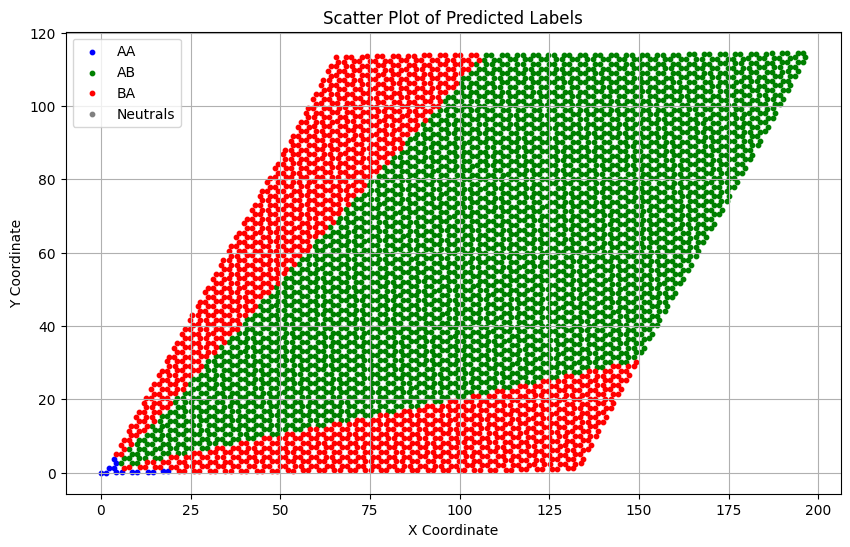

Point (50.0, 75.0) is classified as: BA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.cluster import DBSCAN

# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    return stacking

# 거리 계산 함수
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmed:
        label = "Neutral"

    return label

from scipy.spatial import cKDTree

def reclassify_neutral_points(df, k=7):
    """
    'Neutral'로 분류된 포인트들을 재분류하는 함수.

    주위 k개의 가장 가까운 이웃 포인트 중 'AA', 'AB', 'BA'가 있으면 해당 클래스로 재분류하고,
    그렇지 않으면 'Neutrals'로 유지합니다.

    Parameters:
    - df: 입력 데이터프레임
    - k: 가장 가까운 이웃 포인트의 수

    Returns:
    - df: 재분류된 데이터프레임
    """
    # 'Neutral'로 분류된 포인트들을 선택
    neutral_points = df[df['label'] == 'Neutral']

    if neutral_points.empty:
        return df

    # 'AA', 'AB', 'BA' 레이블을 가진 포인트들 선택
    non_neutral_points = df[df['label'].isin(['AA', 'AB', 'BA'])]

    # KDTree 생성 (빠르게 가장 가까운 이웃을 찾기 위함)
    tree = cKDTree(non_neutral_points[['lower_x', 'lower_y']].values)

    # Neutral 포인트들에 대해 가장 가까운 k개의 이웃을 찾기
    for idx, point in neutral_points.iterrows():
        point_coords = np.array([[point['lower_x'], point['lower_y']]])
        distances, indices = tree.query(point_coords, k=k)

        # 가까운 k개의 이웃의 레이블을 확인
        neighbor_labels = non_neutral_points.iloc[indices[0]]['label'].values

        # 'AA', 'AB', 'BA' 중 가장 많은 레이블로 재분류
        if any(np.isin(neighbor_labels, ['AA', 'AB', 'BA'])):
            most_common_label = pd.Series(neighbor_labels).mode()[0]
            df.at[idx, 'label'] = most_common_label
        else:
            df.at[idx, 'label'] = 'Neutrals'

    return df

# # DBSCAN을 사용하여 Neutral 포인트를 재분류하는 함수
# def reclassify_neutral_points_with_dbscan(df, eps=3, min_samples=5):
#     neutral_points = df[df['label'] == 'Neutral']
#     if neutral_points.empty:
#         return df

#     # AB, AA, BA만 사용하여 DBSCAN을 수행할 데이터 준비
#     df_no_neutral = df[df['label'].isin(['AB', 'AA', 'BA'])]
#     X = df_no_neutral[['lower_x', 'lower_y']]
#     y = df_no_neutral['label']

#     # DBSCAN 클러스터링
#     dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#     dbscan.fit(X)

#     # Cluster labels
#     df_no_neutral['cluster'] = dbscan.labels_

#     # DBSCAN 결과를 사용하여 Neutral 포인트 재분류
#     for idx, point in neutral_points.iterrows():
#         point_coords = np.array([[point['lower_x'], point['lower_y']]])
#         distances = np.linalg.norm(X.values - point_coords, axis=1)
#         nearest_neighbors = np.argsort(distances)[:min_samples]
#         neighbor_labels = y.iloc[nearest_neighbors]

#         # 주변에 AA, AB, BA가 하나라도 있는지 확인
#         if any(neighbor_labels.isin(['AB', 'AA', 'BA'])):
#             most_common_label = neighbor_labels.mode()[0]
#             df.at[idx, 'label'] = most_common_label
#         else:
#             df.at[idx, 'label'] = "Neutrals"

#     return df

# 딥러닝 모델 (PyTorch 사용)
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 4)  # Output: 4 classes (AA, AB, BA, Neutrals)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 데이터를 학습할 함수
def train_model(df):
    X = df[['lower_x', 'lower_y']].values
    y = df['label'].replace({'AA': 0, 'AB': 1, 'BA': 2, 'Neutrals': 3}).values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # PyTorch Tensor로 변환
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # 학습
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            _, predicted = torch.max(outputs.data, 1)
            accuracy = (predicted == y_train).sum().item() / y_train.size(0)
            print(f'Epoch {epoch}, Loss: {loss.item()}, Accuracy: {accuracy * 100:.2f}%')

    # 테스트
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs.data, 1)
        accuracy = (predicted == y_test).sum().item() / y_test.size(0)
        print(f'Test Accuracy: {accuracy * 100:.2f}%')

    return model

# 예측 함수
def predict(model, x, y):
    point = torch.tensor([[x, y]], dtype=torch.float32)
    with torch.no_grad():
        outputs = model(point)
        _, predicted = torch.max(outputs.data, 1)
    return ['AA', 'AB', 'BA', 'Neutrals'][predicted.item()]

# 학습 데이터에 대한 예측 및 시각화 함수
def plot_predictions(model, df):
    X = df[['lower_x', 'lower_y']].values
    y_true = df['label']

    # PyTorch Tensor로 변환하여 예측 수행
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        outputs = model(X_tensor)
        _, y_pred = torch.max(outputs.data, 1)

    # 예측된 레이블을 원래 레이블로 변환
    y_pred_labels = ['AA', 'AB', 'BA', 'Neutrals']
    y_pred = [y_pred_labels[pred] for pred in y_pred]

    # Scatter plot 생성
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutrals': 'gray'}

    for label in colors.keys():
        subset = X[np.array(y_pred) == label]
        plt.scatter(subset[:, 0], subset[:, 1], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Scatter Plot of Predicted Labels')
    plt.legend()
    plt.grid(True)
    plt.show()

# 전체 워크플로 실행
def main():
    # 데이터 경로 설정
    file_path = '/content/gdrive/MyDrive/Untitled Folder/rewq.txt'

    # 데이터 로드 및 전처리
    df = load_and_preprocess_data(file_path)

    # DBSCAN을 사용하여 Neutral 포인트 재분류
    # df = reclassify_neutral_points_with_dbscan(df)
    reclassify_neutral_points(df, k=7)
    # 모델 학습
    model = train_model(df)

    # 학습 데이터의 예측 결과 시각화
    plot_predictions(model, df)

    # 임의의 지점 분류
    x_test = 50.0  # 예시 x 값
    y_test = 75.0  # 예시 y 값
    predicted_label = predict(model, x_test, y_test)
    print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

if __name__ == "__main__":
    main()


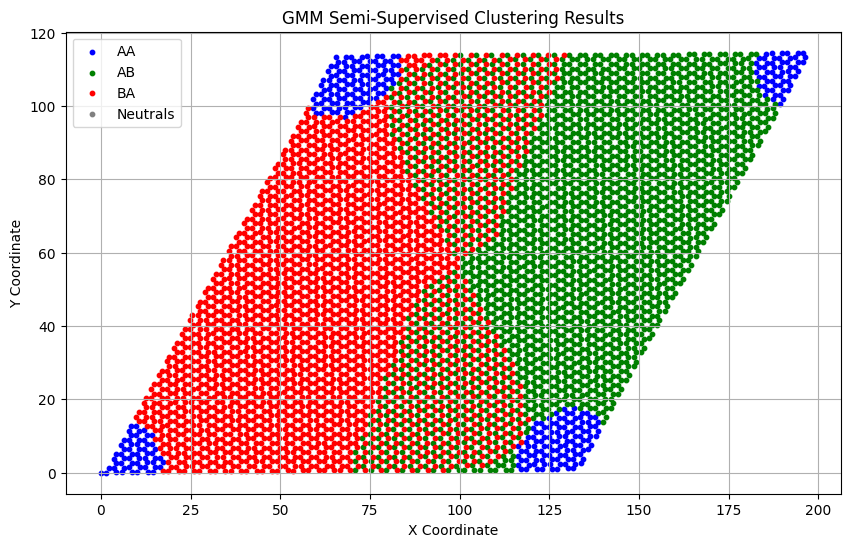

Point (50.0, 75.0) is classified as: Neutrals


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import cKDTree

# 데이터 로드 및 전처리 함수 (기존 코드 사용)
def load_and_preprocess_data(file_path):
    with open(file_path, 'r') as file:
        data = file.read()

    atoms = []
    for line in data.splitlines():
        if line.startswith("ITEM: ATOMS"):
            continue
        elif line.startswith("ITEM") or line.startswith("0"):
            continue
        else:
            atom_info = line.split()
            if len(atom_info) == 8:
                atom_id = int(atom_info[0])
                atom_type = int(atom_info[1])
                x = float(atom_info[2])
                y = float(atom_info[3])
                z = float(atom_info[4])
                atoms.append((atom_id, atom_type, x, y, z))

    df = pd.DataFrame(atoms, columns=["id", "type", "x", "y", "z"])

    # 윗 층과 아랫 층 나누기
    upper_layer = df[df['type'].isin([1, 2])]
    lower_layer = df[df['type'].isin([3, 4])]

    u_coords = upper_layer[['x', 'y', 'z', 'type']]
    l_coords = lower_layer[['x', 'y', 'z', 'type']]

    # 최단 거리 계산 및 레이블 할당
    atom_identify = np.array([find_closest_upper_point(l1, u_coords.values) for l1 in l_coords.values])

    xy = np.concatenate((l_coords.values, atom_identify), axis=1)
    stacking = pd.DataFrame(xy, columns=['lower_x', 'lower_y', 'lower_z', 'ltype', 'upper_x', 'upper_y', 'upper_z', 'utype'])

    # 거리 계산 및 추가
    stacking['distance'] = stacking.apply(lambda row: calculate_distance(row['lower_x'], row['lower_y'], row['upper_x'], row['upper_y']), axis=1)

    # 레이블 할당
    d = np.array([np.sort(np.linalg.norm(l1 - u_coords.values[:, :2], axis=1))[1] for l1 in u_coords.values[:, :2]])
    dmed = np.median(d) / 2
    stacking['label'] = stacking.apply(assign_label, axis=1, dmed=dmed)

    return stacking

# 거리 계산 함수 (기존 코드 사용)
def calculate_distance(lx, ly, ux, uy):
    return np.sqrt((lx - ux)**2 + (ly - uy)**2)

# 최단 거리와 관련된 윗 층의 점 찾기 함수 (기존 코드 사용)
def find_closest_upper_point(lower_point, upper_points):
    distances = np.linalg.norm(upper_points[:, :2] - lower_point[:2], axis=1)
    min_index = np.argmin(distances)
    return upper_points[min_index]

# 레이블 할당 함수 (기존 코드 사용)
def assign_label(row, dmed):
    lx, ly, ltype, ux, uy, utype = row['lower_x'], row['lower_y'], row['ltype'], row['upper_x'], row['upper_y'], row['utype']
    distance = calculate_distance(lx, ly, ux, uy)

    if ltype == 3 and utype == 2:
        label = "BA"
    elif ltype == 3 and utype == 1:
        label = "AA"
    elif ltype == 4 and utype == 2:
        label = "AA"
    elif ltype == 4 and utype == 1:
        label = "AB"
    else:
        label = "exception"

    if distance > dmed:
        label = "Neutral"

    return label

# GMM 기반 Semi-Supervised Learning
def gmm_semi_supervised(df, n_components=4):
    X = df[['lower_x', 'lower_y']].values
    y = df['label']

    # 레이블이 있는 데이터와 없는 데이터를 분리
    labeled_mask = y.isin(['AA', 'AB', 'BA'])
    unlabeled_mask = ~labeled_mask

    X_labeled = X[labeled_mask]
    y_labeled = y[labeled_mask]
    X_unlabeled = X[unlabeled_mask]

    # GMM을 사용해 전체 데이터를 클러스터링
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X)

    # 레이블이 있는 데이터의 클러스터 할당
    labeled_clusters = gmm.predict(X_labeled)

    # 각 클러스터에 레이블 매핑
    cluster_map = {}
    for cluster in range(n_components):
        mask = labeled_clusters == cluster
        if mask.sum() > 0:
            most_common_label = y_labeled[mask].mode()[0]
            cluster_map[cluster] = most_common_label

    # 레이블이 없는 데이터에 대한 클러스터 할당 및 레이블링
    unlabeled_clusters = gmm.predict(X_unlabeled)
    predicted_labels = [cluster_map[cluster] for cluster in unlabeled_clusters]

    # 최종 데이터프레임에 레이블 할당
    df.loc[labeled_mask, 'label'] = y_labeled.values
    df.loc[unlabeled_mask, 'label'] = predicted_labels

    return df, gmm

# Clustering 결과를 시각화하는 함수
def plot_gmm_clusters(df):
    plt.figure(figsize=(10, 6))
    colors = {'AA': 'blue', 'AB': 'green', 'BA': 'red', 'Neutrals': 'gray'}

    for label in colors.keys():
        subset = df[df['label'] == label]
        plt.scatter(subset['lower_x'], subset['lower_y'], c=colors[label], label=label, s=10)

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('GMM Semi-Supervised Clustering Results')
    plt.legend()
    plt.grid(True)
    plt.show()

# 전체 워크플로 실행
def main():
    # 데이터 경로 설정
    file_path = '/content/gdrive/MyDrive/Untitled Folder/qwer.txt'

    # 데이터 로드 및 전처리
    df = load_and_preprocess_data(file_path)

    # 'Neutral' 포인트 재분류
    df = reclassify_neutral_points(df, k=7)

    # GMM을 사용하여 Semi-Supervised Learning 수행
    df, gmm_model = gmm_semi_supervised(df)

    # 군집화 결과 시각화
    plot_gmm_clusters(df)

    # 학습된 GMM 모델로 예측 수행
    x_test = 50.0  # 예시 x 값
    y_test = 75.0  # 예시 y 값
    test_point = np.array([[x_test, y_test]])
    cluster_label = gmm_model.predict(test_point)[0]
    label_map = {0: 'AA', 1: 'AB', 2: 'BA', 3: 'Neutrals'}
    predicted_label = label_map[cluster_label]
    print(f"Point ({x_test}, {y_test}) is classified as: {predicted_label}")

if __name__ == "__main__":
    main()
